# Experiment — multi-branch CNN + squeeze-excitation (discarded)

A deliberately heavier encoder: `MultiBranchConv1D` (parallel kernels), `SqueezeExcite1D` channel attention and `GaussianNoise` input augmentation, wrapped in `CNN_GRU_Attention_Improved`.

**Best validation weighted-F1: 0.9413**, but the Optuna trials plateaued around 0.86 and the extra capacity overfitted the 661-subject training set. None of these blocks survived into the final pipeline.

---


## Google Drive Connection


In [ ]:
# --- Paths ---------------------------------------------------------------
# Originally executed on Google Colab with the dataset on Google Drive.
# DATA_DIR must contain: pirate_pain_train.csv, pirate_pain_train_labels.csv,
# pirate_pain_test.csv, sample_submission.csv  (see data/README.md)
import os

DATA_DIR = os.environ.get("PIRATE_DATA_DIR", "data")
os.makedirs("models", exist_ok=True)
os.makedirs("artifacts", exist_ok=True)


## Libraries Import


In [2]:
# @title
# Set seed for reproducibility
SEED = 42

# Import necessary libraries
import os

# Set environment variables before importing modules
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['MPLCONFIGDIR'] = os.getcwd() + '/configs/'

# Suppress warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=Warning)

# Import necessary modules
import logging
import random
import numpy as np

# Set seeds for random number generators in NumPy and Python
np.random.seed(SEED)
random.seed(SEED)

# Import PyTorch
import torch
torch.manual_seed(SEED)
from torch import nn
# from torchsummary import summary
from torch.utils.tensorboard import SummaryWriter
from torch.utils.data import TensorDataset, Dataset, DataLoader, WeightedRandomSampler
logs_dir = "tensorboard"
%load_ext tensorboard
!mkdir -p models

if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
else:
    device = torch.device("cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

# Import other libraries
import copy
import shutil
from itertools import product
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configure plot display settings
sns.set(font_scale=1.4)
sns.set_style('white')
plt.rc('font', size=14)
%matplotlib inline

from sklearn.model_selection import StratifiedGroupKFold
import optuna
import torch
import torch.nn as nn
import torch.optim as optim
from torch.cuda.amp import GradScaler
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

PyTorch version: 2.8.0+cu126
Device: cuda


## Exploration and Data Analysis


In [3]:
# Define the window size
WINDOW_SIZE = 200

# Define the stride for overlapping windows
STRIDE = 50

# Define the batch size
BATCH_SIZE = 64

In [4]:
X_train = pd.read_csv('../Dataset/pirate_pain_train.csv')
y_train = pd.read_csv('../Dataset/pirate_pain_train_labels.csv')
X_test = pd.read_csv('../Dataset/pirate_pain_test.csv')

# Remove rows with any missing values
X_train.dropna(axis=0, how='any', inplace=True)
y_train.dropna(axis=0, how='any', inplace=True)
X_test.dropna(axis=0, how='any', inplace=True)

# Check for and drop columns with only one unique value
cols_to_drop = []
for col in X_train.columns:
  if X_train[col].nunique() == 1:
    print(f"Column '{col}' has only one unique value")
    cols_to_drop.append(col)

X_train = X_train.drop(columns=cols_to_drop)

# Check unique values in 'n_legs', 'n_hands', and 'n_eyes'
print("Unique values in 'n_legs':", X_train['n_legs'].unique())
print("Unique values in 'n_hands':", X_train['n_hands'].unique())
print("Unique values in 'n_eyes':", X_train['n_eyes'].unique())

# Define a mapping for string representations of strings to integers
legs_mapping = {
    'two': 2,
    'one+peg_leg': 1
}

hands_mapping = {
    'two': 2,
    'one+hook_hand': 1
}

eyes_mapping = {
    'two': 2,
    'one+eye_patch': 1
}

# Convert 'n_legs', 'n_hands', and 'n_eyes' to integers using the mapping
X_train['n_legs'] = X_train['n_legs'].map(legs_mapping)
X_train['n_hands'] = X_train['n_hands'].map(hands_mapping)
X_train['n_eyes'] = X_train['n_eyes'].map(eyes_mapping)

X_test['n_legs'] = X_test['n_legs'].map(legs_mapping)
X_test['n_hands'] = X_test['n_hands'].map(hands_mapping)
X_test['n_eyes'] = X_test['n_eyes'].map(eyes_mapping)

# Define a mapping of status names to integer labels
label_mapping = {
    'no_pain': 0,
    'low_pain': 1,
    'high_pain': 2
}

# Map status names to integers in the labels set
y_train['label'] = y_train['label'].map(label_mapping)

# Convert 'joint_*' columns to float32 data type to use less memory
for col in X_train.columns:
  if 'joint' in col:
    X_train[col] = X_train[col].astype(np.float32)

for col in X_test.columns:
  if 'joint' in col:
    X_test[col] = X_test[col].astype(np.float32)

# StratifiedGroup Split
df_subjects = (X_train[['sample_index']]
    .drop_duplicates()
    .merge(y_train, on='sample_index')
)

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
train_idx, val_idx = next(sgkf.split(
    df_subjects,
    df_subjects['label'],
    groups=df_subjects['sample_index']
))

train_users = df_subjects.iloc[train_idx]['sample_index'].values
val_users   = df_subjects.iloc[val_idx]['sample_index'].values

df_train = X_train[X_train['sample_index'].isin(train_users)]
df_val   = X_train[X_train['sample_index'].isin(val_users)]

# Define the columns to be normalised
num_joints = 29
joint_cols = [f'joint_{i:02d}' for i in range(num_joints+1)]

# Calculate the minimum and maximum values from the training data only
mins = df_train[joint_cols].min()
maxs = df_train[joint_cols].max()

for df in [df_train, df_val]:
    df[joint_cols] = (df[joint_cols] - mins) / (maxs - mins + 1e-9)

Column 'joint_30' has only one unique value
Unique values in 'n_legs': ['two' 'one+peg_leg']
Unique values in 'n_hands': ['two' 'one+hook_hand']
Unique values in 'n_eyes': ['two' 'one+eye_patch']


In [5]:
import numpy as np

def augment_sequence(X_seq,
                     noise_std=0.01,
                     scale_sigma=0.05,
                     time_warp_sigma=0.05,
                     jitter_prob=0.05,
                     slice_ratio=0.9):
    """Apply multiple augmentations to a sequence of shape (window, features).

    Augmentations:
        - Additive Gaussian Noise
        - Magnitude Scaling
        - Random Time Warping
        - Jitter / Dropout temporal points
        - Random window slicing

    Args:
        X_seq (np.ndarray): Sequence, shape (window, num_features)
        noise_std (float): Standard deviation for Gaussian noise
        scale_sigma (float): Std for magnitude scaling factor
        time_warp_sigma (float): Max relative warp in time axis
        jitter_prob (float): Probability to zero-out each point
        slice_ratio (float): Fraction of sequence to keep for slicing

    Returns:
        np.ndarray: Augmented sequence
    """X_aug = X_seq.copy()
    window, n_features = X_aug.shape

    # Additive Gaussian Noise
    X_aug += np.random.normal(0, noise_std, X_aug.shape)

    # Magnitude Scaling
    factor = np.random.normal(1.0, scale_sigma)
    X_aug *= factor

    # Time warping (simple linear interpolation)
    if time_warp_sigma > 0:
        tt = np.arange(window)
        tt_new = tt + np.random.normal(0, time_warp_sigma * window, size=window)
        tt_new = np.clip(tt_new, 0, window-1)
        for i in range(n_features):
            X_aug[:, i] = np.interp(tt, tt_new, X_aug[:, i])

    # Jitter / dropout temporal points
    mask = np.random.rand(window, n_features) < jitter_prob
    X_aug[mask] = 0.0

    # Random window slicing
    if slice_ratio < 1.0:
        new_len = int(window * slice_ratio)
        start_idx = np.random.randint(0, window - new_len + 1)
        X_aug = X_aug[start_idx:start_idx + new_len]
        # pad back to original length
        if new_len < window:
            pad_len = window - new_len
            X_aug = np.pad(X_aug, ((0, pad_len), (0, 0)), mode='constant')

    return X_aug.astype('float32')

In [6]:
# Define a function to build sequences from the dataset
def build_sequences(df, y_df=None, window=WINDOW_SIZE, stride=STRIDE, is_test=False, augment=False):
    """Build sequences for model training/validation/test with optional augmentation.

    Args:
        df (pd.DataFrame): Input dataframe with dynamic and static features
        y_df (pd.DataFrame, optional): Labels dataframe (None if test set)
        window (int): Sequence length
        stride (int): Step size between windows
        is_test (bool): Whether building sequences for test set (no labels)
        augment (bool): Apply augmentation to dynamic features (train only)

    Returns:
        If is_test=False:
            X_seq (np.ndarray): Dynamic features, shape (num_sequences, window, n_dyn_features)
            X_static (np.ndarray): Static features, shape (num_sequences, n_static_features)
            y_seq (np.ndarray): Labels, shape (num_sequences,)
        If is_test=True:
            X_seq, X_static
    """
    # Define dynamic and static columns
    num_joints = 29
    dyn_cols = [f'pain_survey_{i+1}' for i in range(4)] + [f'joint_{i:02d}' for i in range(num_joints+1)]
    static_cols = ['n_legs','n_hands','n_eyes']

    X_seq, X_static, y_seq = [], [], []

    for sid in df['sample_index'].unique():
        temp = df[df['sample_index']==sid]
        static_vals = temp[static_cols].iloc[0].values.astype('float32')
        dyn_vals = temp[dyn_cols].values.astype('float32')

        # Pad sequence to make it divisible by window
        pad_len = (window - len(dyn_vals) % window) % window
        if pad_len > 0:
            dyn_vals = np.concatenate([dyn_vals, np.zeros((pad_len, len(dyn_cols)), dtype='float32')], axis=0)

        idx = 0
        while idx + window <= len(dyn_vals):
            seq_window = dyn_vals[idx:idx+window]

            # Apply augmentation only on training data
            if augment and not is_test:
                seq_window = augment_sequence(seq_window)

            X_seq.append(seq_window)
            X_static.append(static_vals)

            if not is_test:
                label = y_df[y_df['sample_index']==sid]['label'].values[0]
                y_seq.append(label)

            idx += stride

    X_seq = np.array(X_seq, dtype='float32')
    X_static = np.array(X_static, dtype='float32')
    y_seq = np.array(y_seq, dtype='int64') if not is_test else None

    if is_test:
        return X_seq, X_static
    return X_seq, X_static, y_seq

In [7]:
X_train_seq, X_train_static, y_train_seq = build_sequences(df_train, y_train, augment=True)
X_val_seq, X_val_static, y_val_seq = build_sequences(df_val, y_train, augment=False)

# Print the shapes of the generated datasets and their labels
X_train_seq.shape, y_train_seq.shape, X_val_seq.shape, y_val_seq.shape

((529, 200, 34), (529,), (132, 200, 34), (132,))

In [8]:
# Define the input shape based on the training data
input_shape = X_train_seq.shape[1:]

# Define the number of classes based on the categorical labels
num_classes = len(np.unique(y_train_seq))

input_shape, num_classes

((200, 34), 3)

In [9]:
class PirateDataset(Dataset):
    def __init__(self, X_seq, X_static, y=None):
        self.X_seq = torch.from_numpy(X_seq).float()
        self.X_static = torch.from_numpy(X_static).float()
        self.y = torch.from_numpy(y).long() if y is not None else None

    def __len__(self):
        return len(self.X_seq)

    def __getitem__(self, idx):
        if self.y is not None:
            return self.X_seq[idx], self.X_static[idx], self.y[idx]
        return self.X_seq[idx], self.X_static[idx]

train_ds = PirateDataset(X_train_seq, X_train_static, y_train_seq)
val_ds = PirateDataset(X_val_seq, X_val_static, y_val_seq)

In [10]:
def make_loader(ds, batch_size, shuffle=True, drop_last=False):
    """Create a DataLoader tuned for the Pirate Pain dataset,
    with support for static features and class balancing.
    """
    cpu_cores = os.cpu_count() or 2
    num_workers = max(2, min(4, cpu_cores))

    if hasattr(ds, "y") and ds.y is not None:
        dataset_labels = ds.y.numpy()
    elif hasattr(ds, "tensors") and len(ds.tensors) > 1:
        dataset_labels = ds.tensors[1].numpy()
    else:
        dataset_labels = None

    sampler = None
    if dataset_labels is not None and shuffle:
        class_counts = np.bincount(dataset_labels)
        class_weights = 1.0 / (class_counts + 1e-9)
        sample_weights = class_weights[dataset_labels]
        sampler = WeightedRandomSampler(
            weights=sample_weights,
            num_samples=len(sample_weights),
            replacement=True
        )
        shuffle = False  # Shuffle handled by sampler

    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=num_workers,
        pin_memory=True,
        pin_memory_device="cuda" if torch.cuda.is_available() else "",
        prefetch_factor=4,
        sampler=sampler
    )

In [11]:
# Create data loaders with different settings for each phase
train_loader = make_loader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
val_loader   = make_loader(val_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

In [12]:
# Get one batch from the training data loader
for xb, x_staticb, yb in train_loader:
    print("Dynamic features batch shape:", xb.shape)
    print("Static features batch shape:", x_staticb.shape)
    print("Labels batch shape:", yb.shape)
    break

Dynamic features batch shape: torch.Size([64, 200, 34])
Static features batch shape: torch.Size([64, 3])
Labels batch shape: torch.Size([64])


## Model Building


In [13]:
import torch
from torch import nn
import torch.nn.functional as F

# --- Gaussian Noise (regularization layer) ---
class GaussianNoise(nn.Module):
    def __init__(self, std=1e-2):
        super().__init__()
        self.std = std

    def forward(self, x):
        if self.training and self.std > 0:
            return x + torch.randn_like(x) * self.std
        return x


# --- Multi-branch CNN (3 kernel sizes + residual connection) ---
class MultiBranchConv1D(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1):
        super().__init__()
        ch1 = out_ch // 3
        ch2 = out_ch // 3
        ch3 = out_ch - ch1 - ch2
        self.b3 = nn.Conv1d(in_ch, ch1, kernel_size=3, padding=1)
        self.b5 = nn.Conv1d(in_ch, ch2, kernel_size=5, padding=2)
        self.b9 = nn.Conv1d(in_ch, ch3, kernel_size=9, padding=4)
        self.bn = nn.BatchNorm1d(out_ch)
        self.act = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.res = nn.Conv1d(in_ch, out_ch, kernel_size=1) if in_ch != out_ch else nn.Identity()

    def forward(self, x):
        a = self.b3(x)
        b = self.b5(x)
        c = self.b9(x)
        out = torch.cat([a, b, c], dim=1)
        out = self.bn(out)
        out = self.dropout(out)
        return self.act(out + self.res(x))


# --- Channel-wise Squeeze & Excitation ---
class SqueezeExcite1D(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        self.fc1 = nn.Linear(channels, channels // reduction)
        self.fc2 = nn.Linear(channels // reduction, channels)

    def forward(self, x):
        s = x.mean(dim=2)
        s = F.relu(self.fc1(s))
        s = torch.sigmoid(self.fc2(s))
        s = s.unsqueeze(-1)
        return x * s


# --- Main Hybrid Model ---
class CNN_GRU_Attention_Improved(nn.Module):
    def __init__(
        self,
        input_size: int,    # dynamic features per timestep
        static_size: int,   # number of static features
        num_classes: int,
        cnn_channels: int = 128,
        hidden_size: int = 128,
        num_layers: int = 2,
        dropout: float = 0.3,
        num_heads: int = 4,
        noise_std: float = 1e-2,
        bidirectional: bool = True,
    ):
        super().__init__()

        self.noise = GaussianNoise(std=noise_std)
        self.bidirectional = bidirectional

        # --- CNN feature extractor ---
        self.cnn1 = MultiBranchConv1D(input_size, 64, dropout=dropout)
        self.cnn2 = MultiBranchConv1D(64, cnn_channels, dropout=dropout)
        self.se = SqueezeExcite1D(cnn_channels, reduction=8)

        # --- GRU encoder ---
        self.gru = nn.GRU(
            input_size=cnn_channels,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=bidirectional
        )

        gru_out_dim = hidden_size * (2 if bidirectional else 1)

        # --- Normalization + Attention ---
        self.layernorm = nn.LayerNorm(gru_out_dim)
        self.attn = nn.MultiheadAttention(
            embed_dim=gru_out_dim,
            num_heads=num_heads,
            batch_first=True
        )

        # --- Static feature fusion ---
        self.static_proj = nn.Sequential(
            nn.Linear(static_size, gru_out_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        self.static_gate = nn.Sequential(
            nn.Linear(static_size, gru_out_dim),
            nn.Sigmoid()
        )

        # --- Classifier head ---
        self.fc = nn.Sequential(
            nn.Linear(gru_out_dim, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )

    def forward(self, x, static=None):
        """
        x: (B, T, input_size)
        static: (B, static_size) or None
        returns logits (B, num_classes)
        """
        x = self.noise(x)

        # CNN expects (B, C, T)
        x = x.permute(0, 2, 1)
        x = self.cnn1(x)
        x = self.cnn2(x)
        x = self.se(x)

        # Back to GRU format (B, T, C)
        x = x.permute(0, 2, 1)

        # GRU
        out, _ = self.gru(x)
        out = self.layernorm(out)

        # Self-attention
        attn_out, _ = self.attn(out, out, out)

        # Mean pooling over time
        pooled = attn_out.mean(dim=1)

        # --- Static fusion ---
        if static is not None:
            static_proj = self.static_proj(static)
            gate = self.static_gate(static)
            fused = pooled * gate + static_proj
        else:
            fused = pooled

        # --- Classification ---
        logits = self.fc(fused)
        return logits

## Network and Training Hyperparameters


In [14]:
label_counts = y_train['label'].value_counts().values

counts = torch.tensor(label_counts, dtype=torch.float)
weights = counts.sum() / (counts * len(counts))
weights

tensor([0.4312, 2.3440, 3.9345])

In [15]:
# Training configuration
LEARNING_RATE = 1e-3
EPOCHS = 500
PATIENCE = 100

# Architecture
HIDDEN_LAYERS = 2        # Hidden layers
HIDDEN_SIZE = 128        # Neurons per layer

# Regularisation
DROPOUT_RATE = 0.2         # Dropout probability
L1_LAMBDA = 0.001          # L1 penalty
L2_LAMBDA = 0.001          # L2 penalty

# Set up loss function and optimizer
# criterion = nn.CrossEntropyLoss(weight=weights.to(device))
# criterion = nn.CrossEntropyLoss()
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

# Path for model savings
BASE_PATH = ""

## Model Training


In [16]:
# Initialize best model tracking variables
best_model = None
best_performance = float('-inf')

In [17]:
from tqdm import tqdm
from sklearn.metrics import f1_score
import numpy as np
import torch

def train_one_epoch(model, train_loader, criterion, optimizer, scaler, device,
                    l1_lambda=0.0, l2_lambda=0.0, max_grad_norm=1.0, use_tqdm=True):
    """Train the model for one epoch.

    Args:
        model (nn.Module): Neural network model
        train_loader (DataLoader): Loader yielding (x_dyn, x_static, y)
        criterion (nn.Module): Loss function
        optimizer (torch.optim.Optimizer)
        scaler (torch.cuda.amp.GradScaler)
        device (torch.device)
        l1_lambda (float): L1 regularization coefficient
        l2_lambda (float): L2 regularization coefficient
        max_grad_norm (float): Clip gradient norm to avoid exploding gradients
        use_tqdm (bool): Whether to show progress bar

    Returns:
        tuple: (avg_loss, weighted_f1)
    """
    model.train()

    running_loss = 0.0
    all_preds, all_tgts = [], []

    loader_iter = tqdm(train_loader, desc="Training", leave=False) if use_tqdm else train_loader

    for xb_dyn, xb_static, yb in loader_iter:
        xb_dyn = xb_dyn.to(device).float()
        xb_static = xb_static.to(device).float()
        yb = yb.to(device)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type=device.type, enabled=(device.type == "cuda")):
            logits = model(xb_dyn, static=xb_static)
            loss = criterion(logits, yb)
            loss = torch.nan_to_num(loss)

            if l1_lambda > 0:
                l1_norm = sum(p.abs().sum() for p in model.parameters())
                loss += l1_lambda * l1_norm

            if l2_lambda > 0:
                l2_norm = sum(p.pow(2).sum() for p in model.parameters())
                loss += l2_lambda * l2_norm

        scaler.scale(loss).backward()

        if max_grad_norm is not None:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)

        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * xb_dyn.size(0)

        preds = logits.argmax(dim=1)
        all_preds.append(preds.cpu())
        all_tgts.append(yb.cpu())

    # Aggregate results
    all_preds = torch.cat(all_preds).numpy()
    all_tgts = torch.cat(all_tgts).numpy()

    avg_loss = running_loss / len(train_loader.dataset)
    avg_f1 = f1_score(all_tgts, all_preds, average="weighted")

    return avg_loss, avg_f1

In [18]:
from sklearn.metrics import f1_score
import numpy as np
import torch
from tqdm import tqdm

def validate_one_epoch(model, val_loader, criterion, device, use_tqdm=True):
    """Evaluate the model on the validation set for one full epoch.

    Args:
        model (nn.Module): Neural network to evaluate
        val_loader (DataLoader): Loader yielding (x_dyn, x_static, y)
        criterion (nn.Module): Loss function
        device (torch.device): 'cuda' or 'cpu'
        use_tqdm (bool): Show progress bar if True

    Returns:
        tuple: (avg_loss, weighted_f1)
    """
    model.eval()

    running_loss = 0.0
    all_preds, all_tgts = [], []

    loader_iter = tqdm(val_loader, desc="Validating", leave=False) if use_tqdm else val_loader

    with torch.no_grad():
        for xb_dyn, xb_static, yb in loader_iter:
            xb_dyn = xb_dyn.to(device).float()
            xb_static = xb_static.to(device).float()
            yb = yb.to(device)

            with torch.amp.autocast(device_type=device.type, enabled=(device.type == "cuda")):
                logits = model(xb_dyn, static=xb_static)
                loss = criterion(logits, yb)
                loss = torch.nan_to_num(loss)

            running_loss += loss.item() * xb_dyn.size(0)

            preds = logits.argmax(dim=1)
            all_preds.append(preds.cpu())
            all_tgts.append(yb.cpu())

    all_preds = torch.cat(all_preds).numpy()
    all_tgts = torch.cat(all_tgts).numpy()

    avg_loss = running_loss / len(val_loader.dataset)
    avg_f1 = f1_score(all_tgts, all_preds, average="weighted")

    return avg_loss, avg_f1

In [19]:
def log_metrics_to_tensorboard(writer, epoch, train_loss, train_f1, val_loss, val_f1, model):
    """Log training metrics and model parameters to TensorBoard for visualization.

    Args:
        writer (SummaryWriter): TensorBoard SummaryWriter object for logging
        epoch (int): Current epoch number (used as x-axis in TensorBoard plots)
        train_loss (float): Training loss for this epoch
        train_f1 (float): Training f1 score for this epoch
        val_loss (float): Validation loss for this epoch
        val_f1 (float): Validation f1 score for this epoch
        model (nn.Module): The neural network model (for logging weights/gradients)

    Note:
        This function logs scalar metrics (loss/f1 score) and histograms of model
        parameters and gradients, which helps monitor training progress and detect
        issues like vanishing/exploding gradients.
    """
    # Log scalar metrics
    writer.add_scalar('Loss/Training', train_loss, epoch)
    writer.add_scalar('Loss/Validation', val_loss, epoch)
    writer.add_scalar('F1/Training', train_f1, epoch)
    writer.add_scalar('F1/Validation', val_f1, epoch)

    # Log model parameters and gradients
    for name, param in model.named_parameters():
        if param.requires_grad:
            # Check if the tensor is not empty before adding a histogram
            if param.numel() > 0:
                writer.add_histogram(f'{name}/weights', param.data, epoch)
            if param.grad is not None:
                # Check if the gradient tensor is not empty before adding a histogram
                if param.grad.numel() > 0:
                    if param.grad is not None and torch.isfinite(param.grad).all():
                        writer.add_histogram(f'{name}/gradients', param.grad.data, epoch)

In [32]:
def fit(model, train_loader, val_loader, epochs, criterion, optimizer, scaler, device,
        l1_lambda=0, l2_lambda=0, patience=0, evaluation_metric="val_f1", mode='max',
        restore_best_weights=True, writer=None, verbose=10, experiment_name="", base_path="", scheduler=None):
    """Train the neural network model on the training data and validate on the validation data.
    """

    training_history = {
        'train_loss': [], 'val_loss': [],
        'train_f1': [], 'val_f1': []
    }

    if patience > 0:
        patience_counter = 0
        best_metric = float('-inf') if mode == 'max' else float('inf')
        best_epoch = 0

    print(f"Training for {epochs} epochs...\n")

    for epoch in range(1, epochs + 1):
        # Training phase
        train_loss, train_f1 = train_one_epoch(
            model=model,
            train_loader=train_loader,
            criterion=criterion,
            optimizer=optimizer,
            scaler=scaler,
            device=device,
            l1_lambda=l1_lambda,
            l2_lambda=l2_lambda,
            use_tqdm=False
        )

        # Validation phase
        val_loss, val_f1 = validate_one_epoch(
            model=model,
            val_loader=val_loader,
            criterion=criterion,
            device=device,
            use_tqdm=False
        )

        # Optional scheduler step
        if scheduler is not None:
            metric_to_track = val_f1 if evaluation_metric == "val_f1" else val_loss
            scheduler.step(metric_to_track)

        # Log metrics
        training_history['train_loss'].append(train_loss)
        training_history['val_loss'].append(val_loss)
        training_history['train_f1'].append(train_f1)
        training_history['val_f1'].append(val_f1)

        if writer is not None:
            writer.add_scalar("Loss/train", train_loss, epoch)
            writer.add_scalar("Loss/val", val_loss, epoch)
            writer.add_scalar("F1/train", train_f1, epoch)
            writer.add_scalar("F1/val", val_f1, epoch)

        if verbose > 0 and (epoch % verbose == 0 or epoch == 1):
            print(f"Epoch {epoch:03d}/{epochs} | "
                  f"Train: Loss={train_loss:.4f}, F1={train_f1:.4f} | "
                  f"Val: Loss={val_loss:.4f}, F1={val_f1:.4f}")

        # Early stopping logic
        if patience > 0:
            current_metric = training_history[evaluation_metric][-1]
            improved = (current_metric > best_metric) if mode == 'max' else (current_metric < best_metric)

            if improved:
                best_metric = current_metric
                best_epoch = epoch
                torch.save(model.state_dict(), f"{base_path}models/{experiment_name}_best.pt")
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"Early stopping triggered at epoch {epoch}")
                    break

    # Restore best weights if applicable
    if restore_best_weights and patience > 0 and best_epoch > 0:
        model.load_state_dict(torch.load(f"{base_path}models/{experiment_name}_best.pt"))
        print(f"Restored best model from epoch {best_epoch} ({evaluation_metric}: {best_metric:.4f})")

    # Save final weights if early stopping disabled
    if patience == 0:
        torch.save(model.state_dict(), f"{base_path}models/{experiment_name}_final.pt")

    if writer is not None:
        writer.close()

    return model, training_history

## Optuna


In [29]:
import optuna
import torch
import torch.nn as nn
from torch.cuda.amp import GradScaler
from sklearn.model_selection import StratifiedKFold
import numpy as np

def objective(trial):
    # === Hyperparameter search space ===
    cnn_channels = trial.suggest_int("cnn_channels", 64, 256, step=32)
    hidden_size = trial.suggest_int("hidden_size", 64, 256, step=32)
    num_layers = trial.suggest_int("num_layers", 1, 3)
    dropout = trial.suggest_float("dropout", 0.0, 0.5)

    # Change: Suggest num_heads from a fixed integer range to avoid dynamic value space error.
    num_heads = trial.suggest_int("num_heads", 2, 8)

    noise_std = trial.suggest_float("noise_std", 1e-3, 1e-1, log=True)
    bidirectional = trial.suggest_categorical("bidirectional", [True, False])

    # Constraint for MultiheadAttention: embed_dim must be divisible by num_heads.
    # embed_dim is gru_out_dim.
    gru_out_dim = hidden_size * (2 if bidirectional else 1)
    if gru_out_dim % num_heads != 0:
        raise optuna.TrialPruned() # Prune trial if condition is not met.

    # Training parameters
    lr = trial.suggest_float("lr", 1e-4, 5e-3, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
    batch_size = trial.suggest_categorical("batch_size", [32, 64, 128])
    l1_lambda = trial.suggest_loguniform("l1_lambda", 1e-8, 1e-3)
    l2_lambda = trial.suggest_loguniform("l2_lambda", 1e-8, 1e-3)

    # Loss parameters
    loss_variant = trial.suggest_categorical("loss_variant", ["plain", "weighted", "smoothed"])
    # label_smoothing is only relevant if loss_variant is "smoothed"
    label_smoothing = trial.suggest_float("label_smoothing", 0.0, 0.1) if loss_variant == "smoothed" else 0.0

    # Scheduler
    scheduler_type = trial.suggest_categorical("scheduler", ["cosine", "onecycle"])

    # Sequence parameters
    WINDOW_SIZE = trial.suggest_categorical("window_size", [100, 150, 200, 250])
    # Change: Suggest STRIDE from a fixed categorical list to avoid dynamic value space error.
    STRIDE = trial.suggest_categorical("stride", [25, 50])

    # === K-Fold setup ===
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    f1_scores = []

    # Assuming X_train_seq, y_train_seq, df_train are already defined
    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_seq, y_train_seq)):
        # Split dynamic + static + labels
        X_tr, X_val = X_train_seq[train_idx], X_train_seq[val_idx]
        y_tr, y_val = y_train_seq[train_idx], y_train_seq[val_idx]

        # Change: Correctly split static features using X_train_static
        X_tr_static, X_val_static = X_train_static[train_idx], X_train_static[val_idx]

        # Datasets & Loaders
        train_ds = PirateDataset(X_tr, X_tr_static, y_tr)
        val_ds   = PirateDataset(X_val, X_val_static, y_val)
        # Change: Set drop_last=True for train_loader to prevent single-sample batches.
        train_loader = make_loader(train_ds, batch_size=batch_size, shuffle=True, drop_last=True)
        val_loader   = make_loader(val_ds, batch_size=batch_size, shuffle=False)

        # Class weights for weighted loss
        counts = np.bincount(y_tr)
        class_weights = torch.tensor(1.0 / (counts + 1e-9), dtype=torch.float32).to(device)
        class_weights /= class_weights.sum()

        # Loss function
        # Change: Adjusted criterion setting for smoothed loss.
        if loss_variant == "weighted":
            criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=label_smoothing)
        elif loss_variant == "smoothed":
            criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
        else: # "plain"
            criterion = nn.CrossEntropyLoss()

        # Input sizes
        input_size = X_tr.shape[2]  # number of dynamic features per timestep
        static_size = X_tr_static.shape[1]  # number of static features
        num_classes = len(np.unique(y_tr))

        # Model
        model = CNN_GRU_Attention_Improved(
            input_size=input_size,
            static_size=static_size,
            num_classes=num_classes,
            cnn_channels=cnn_channels,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout,
            num_heads=num_heads, # Use the suggested num_heads directly
            noise_std=noise_std,
            bidirectional=bidirectional
        ).to(device)

        # Optimizer, scheduler, scaler
        optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
        scaler = GradScaler(enabled=(device.type == "cuda"))

        if scheduler_type == "cosine":
            scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10, eta_min=lr/50)
        else:  # onecycle
            scheduler = torch.optim.lr_scheduler.OneCycleLR(
                optimizer, max_lr=lr, steps_per_epoch=len(train_loader), epochs=100
            )

        # === Train model using your fit() ===
        model, history = fit(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            epochs=100,
            criterion=criterion,
            optimizer=optimizer,
            scaler=scaler,
            device=device,
            l1_lambda=l1_lambda,
            l2_lambda=l2_lambda,
            patience=20, # Reduced patience for faster Optuna trials.
            evaluation_metric="val_f1",
            scheduler=scheduler,
            verbose=0
        )

        best_f1 = max(history["val_f1"])
        f1_scores.append(best_f1)

        # Optuna pruning
        trial.report(best_f1, fold)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return np.mean(f1_scores)

In [30]:
def print_best_params_callback(study, trial):
    best_trial = study.best_trial
    print(f"\nCurrent Best F1: {best_trial.value:.4f}")
    print("Current Best Params:")
    for k, v in best_trial.params.items():
        print(f"  {k}: {v}")

In [33]:
study = optuna.create_study(direction="maximize", study_name="pirate_pain_tuning")
study.optimize(objective, n_trials=30, timeout=None, show_progress_bar=True, callbacks=[print_best_params_callback])

print("Best trial:")
trial = study.best_trial
print(f"F1 = {trial.value:.4f}")
for k, v in trial.params.items():
    print(f"{k}: {v}")

[I 2025-11-13 17:20:42,418] A new study created in memory with name: pirate_pain_tuning


  0%|          | 0/30 [00:00<?, ?it/s]

Training for 100 epochs...

Restored best model from epoch 99 (val_f1: 0.6797)
Training for 100 epochs...

Early stopping triggered at epoch 21
Restored best model from epoch 1 (val_f1: 0.6847)
Training for 100 epochs...

Early stopping triggered at epoch 22
Restored best model from epoch 2 (val_f1: 0.6981)
[I 2025-11-13 17:22:21,378] Trial 0 finished with value: 0.6874704119357721 and parameters: {'cnn_channels': 192, 'hidden_size': 64, 'num_layers': 2, 'dropout': 0.16517493339328587, 'num_heads': 8, 'noise_std': 0.045783539118231846, 'bidirectional': False, 'lr': 0.0001703326896721109, 'weight_decay': 0.0004150234362277813, 'batch_size': 32, 'l1_lambda': 1.5029633323650265e-08, 'l2_lambda': 1.493339457915483e-08, 'loss_variant': 'smoothed', 'label_smoothing': 0.05666005267683924, 'scheduler': 'onecycle', 'window_size': 200, 'stride': 50}. Best is trial 0 with value: 0.6874704119357721.

Current Best F1: 0.6875
Current Best Params:
  cnn_channels: 192
  hidden_size: 64
  num_layers: 2

## Training


In [37]:
WINDOW_SIZE = 250
STRIDE = 50

X_train_seq, X_train_static, y_train_seq = build_sequences(df_train, y_train, augment=True, window=WINDOW_SIZE, stride=STRIDE)
X_val_seq, X_val_static, y_val_seq = build_sequences(df_val, y_train, augment=False, window=WINDOW_SIZE, stride=STRIDE)
input_shape = X_train_seq.shape[1:]
num_classes = len(np.unique(y_train_seq))
train_ds = PirateDataset(X_train_seq, X_train_static, y_train_seq)
val_ds = PirateDataset(X_val_seq, X_val_static, y_val_seq)
train_loader = make_loader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
val_loader   = make_loader(val_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

In [38]:
best_params = study.best_trial.params

cnn_channels   = best_params['cnn_channels']
hidden_size    = best_params['hidden_size']
num_layers     = best_params['num_layers']
dropout        = best_params['dropout']
num_heads      = best_params['num_heads']
noise_std      = best_params['noise_std']
bidirectional  = best_params['bidirectional']
lr             = best_params['lr']
weight_decay   = best_params['weight_decay']
l1_lambda      = best_params['l1_lambda']
l2_lambda      = best_params['l2_lambda']
label_smoothing = best_params.get('label_smoothing', 0.0)
batch_size     = best_params['batch_size']

train_loader = make_loader(train_ds, batch_size=batch_size, shuffle=True)
val_loader   = make_loader(val_ds, batch_size=batch_size, shuffle=False)

counts = np.bincount(y_train_seq)
class_weights = torch.tensor(1.0 / (counts + 1e-9), dtype=torch.float32).to(device)
class_weights /= class_weights.sum()

if best_params.get('loss_variant', 'plain') == 'weighted':
    criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=label_smoothing)
else:
    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)

model = CNN_GRU_Attention_Improved(
    input_size=X_train_seq.shape[2],
    static_size=X_train_static.shape[1],
    num_classes=num_classes,
    cnn_channels=cnn_channels,
    hidden_size=hidden_size,
    num_layers=num_layers,
    dropout=dropout,
    num_heads=num_heads,
    noise_std=noise_std,
    bidirectional=bidirectional
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=15
)

scaler = torch.amp.GradScaler(enabled=(device.type == 'cuda'))

experiment_name = "cnn_gru_imp_opt_best"
model, training_history = fit(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    criterion=criterion,
    optimizer=optimizer,
    scaler=scaler,
    device=device,
    verbose=1,
    experiment_name=experiment_name,
    patience=PATIENCE,
    base_path=BASE_PATH,
    scheduler=scheduler
)

best_model = model
best_performance = max(training_history['val_f1'])

print(f"Training complete. Best validation F1: {best_performance:.4f}")

Training for 500 epochs...

Epoch 001/500 | Train: Loss=1.1584, F1=0.3511 | Val: Loss=1.1546, F1=0.0401
Epoch 002/500 | Train: Loss=1.0588, F1=0.4583 | Val: Loss=1.0494, F1=0.1678
Epoch 003/500 | Train: Loss=1.0404, F1=0.4541 | Val: Loss=1.0332, F1=0.3602
Epoch 004/500 | Train: Loss=0.8931, F1=0.5713 | Val: Loss=1.0785, F1=0.3823
Epoch 005/500 | Train: Loss=0.7980, F1=0.6111 | Val: Loss=1.1774, F1=0.3956
Epoch 006/500 | Train: Loss=0.6869, F1=0.6932 | Val: Loss=1.6937, F1=0.3542
Epoch 007/500 | Train: Loss=0.6056, F1=0.7525 | Val: Loss=1.1585, F1=0.5240
Epoch 008/500 | Train: Loss=0.4881, F1=0.7990 | Val: Loss=1.2906, F1=0.5330
Epoch 009/500 | Train: Loss=0.4260, F1=0.8396 | Val: Loss=0.7361, F1=0.7644
Epoch 010/500 | Train: Loss=0.3898, F1=0.8486 | Val: Loss=0.4846, F1=0.8104
Epoch 011/500 | Train: Loss=0.3473, F1=0.8790 | Val: Loss=0.5776, F1=0.8127
Epoch 012/500 | Train: Loss=0.3541, F1=0.8639 | Val: Loss=0.5460, F1=0.8068
Epoch 013/500 | Train: Loss=0.3192, F1=0.8883 | Val: Loss=0.

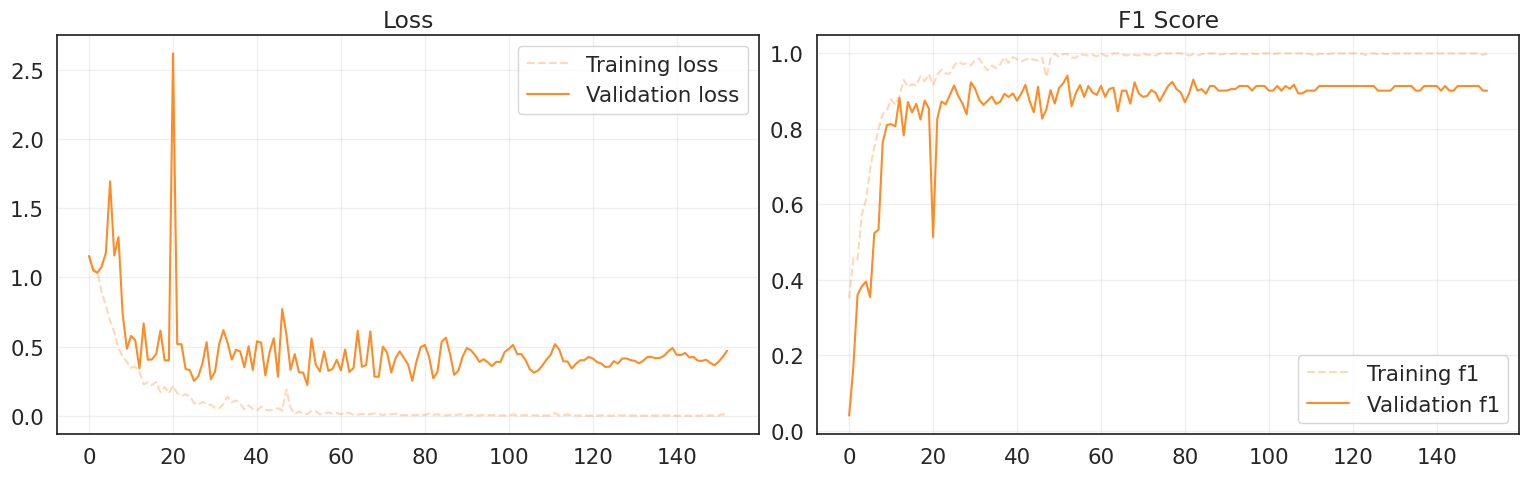

In [39]:
# Create a figure with two side-by-side subplots (two columns)
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(18, 5))

# Plot of training and validation loss on the first axis
ax1.plot(training_history['train_loss'], label='Training loss', alpha=0.3, color='#ff7f0e', linestyle='--')
ax1.plot(training_history['val_loss'], label='Validation loss', alpha=0.9, color='#ff7f0e')
ax1.set_title('Loss')
ax1.legend()
ax1.grid(alpha=0.3)

# Plot of training and validation accuracy on the second axis
ax2.plot(training_history['train_f1'], label='Training f1', alpha=0.3, color='#ff7f0e', linestyle='--')
ax2.plot(training_history['val_f1'], label='Validation f1', alpha=0.9, color='#ff7f0e')
ax2.set_title('F1 Score')
ax2.legend()
ax2.grid(alpha=0.3)

# Adjust the layout and display the plot
plt.tight_layout()
plt.subplots_adjust(right=0.85)
plt.show()

Accuracy over the validation set: 0.9470
Precision over the validation set: 0.9434
Recall over the validation set: 0.9470
F1 score over the validation set: 0.9413


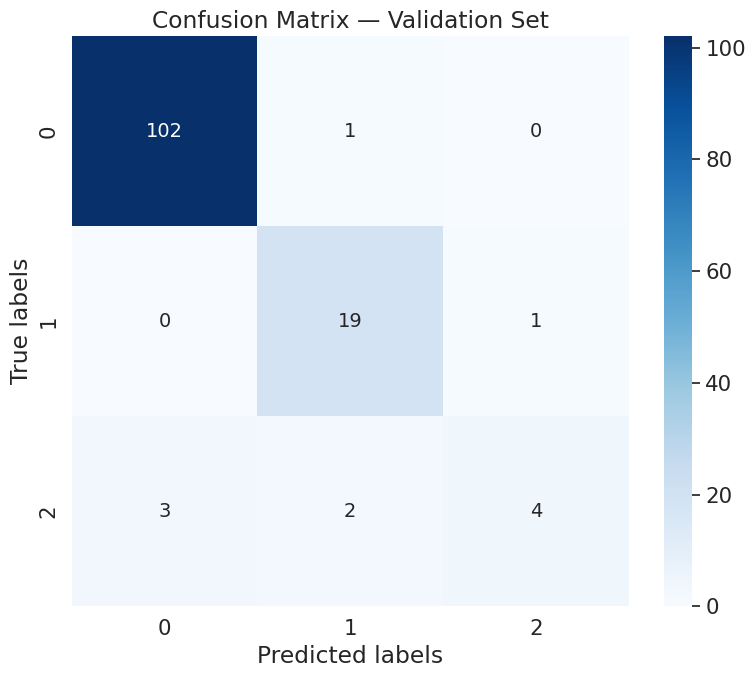

In [40]:
# Collect predictions and ground truth labels
val_preds, val_targets = [], []
model.eval()
with torch.no_grad():  # Disable gradient computation for inference
    for xb_dyn, xb_static, yb in val_loader:
        # Move data to device and convert to float32
        xb_dyn = xb_dyn.to(device).float()
        xb_static = xb_static.to(device).float()
        yb = yb.to(device)

        # Forward pass: get model predictions
        logits = model(xb_dyn, xb_static)
        preds = logits.argmax(dim=1).cpu().numpy()

        # Store batch results
        val_preds.append(preds)
        val_targets.append(yb.cpu().numpy())

# Combine all batches into single arrays
val_preds = np.concatenate(val_preds)
val_targets = np.concatenate(val_targets)

# Calculate overall validation metrics
val_acc = accuracy_score(val_targets, val_preds)
val_prec = precision_score(val_targets, val_preds, average='weighted')
val_rec = recall_score(val_targets, val_preds, average='weighted')
val_f1 = f1_score(val_targets, val_preds, average='weighted')
print(f"Accuracy over the validation set: {val_acc:.4f}")
print(f"Precision over the validation set: {val_prec:.4f}")
print(f"Recall over the validation set: {val_rec:.4f}")
print(f"F1 score over the validation set: {val_f1:.4f}")

# Generate confusion matrix for detailed error analysis
cm = confusion_matrix(val_targets, val_preds)

# Create numeric labels for heatmap annotation
labels = np.array([f"{num}" for num in cm.flatten()]).reshape(cm.shape)

# Visualise confusion matrix
plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=labels, fmt='',
            cmap='Blues')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix — Validation Set')
plt.tight_layout()
plt.show()

## Testing


In [42]:
model = CNN_GRU_Attention_Improved(
    input_size=X_train_seq.shape[2],
    static_size=X_train_static.shape[1],
    num_classes=num_classes,
    cnn_channels=cnn_channels,
    hidden_size=hidden_size,
    num_layers=num_layers,
    dropout=dropout,
    num_heads=num_heads,
    noise_std=noise_std,
    bidirectional=bidirectional
).to(device)

model_path = BASE_PATH+"models/"+"cnn_gru_imp_opt_best_best.pt"

model.load_state_dict(torch.load(model_path, map_location=device))
model.to(device)
model.eval()

CNN_GRU_Attention_Improved(
  (noise): GaussianNoise()
  (cnn1): MultiBranchConv1D(
    (b3): Conv1d(34, 21, kernel_size=(3,), stride=(1,), padding=(1,))
    (b5): Conv1d(34, 21, kernel_size=(5,), stride=(1,), padding=(2,))
    (b9): Conv1d(34, 22, kernel_size=(9,), stride=(1,), padding=(4,))
    (bn): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (act): ReLU()
    (dropout): Dropout(p=0.20265908174721187, inplace=False)
    (res): Conv1d(34, 64, kernel_size=(1,), stride=(1,))
  )
  (cnn2): MultiBranchConv1D(
    (b3): Conv1d(64, 53, kernel_size=(3,), stride=(1,), padding=(1,))
    (b5): Conv1d(64, 53, kernel_size=(5,), stride=(1,), padding=(2,))
    (b9): Conv1d(64, 54, kernel_size=(9,), stride=(1,), padding=(4,))
    (bn): BatchNorm1d(160, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (act): ReLU()
    (dropout): Dropout(p=0.20265908174721187, inplace=False)
    (res): Conv1d(64, 160, kernel_size=(1,), stride=(1,))
  )
  (se

In [55]:
# Check loaded model performance
val_loss, val_f1 = validate_one_epoch(model, val_loader, criterion, device, use_tqdm=False)
print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation F1:   {val_f1:.4f}")

Validation Loss: 0.2224
Validation F1:   0.9413


In [44]:
num_joints = 29
scale_columns = [f'joint_{i:02d}' for i in range(num_joints+1)]

mins = X_test[scale_columns].min()
maxs = X_test[scale_columns].max()

for column in scale_columns:
    X_test[column] = (X_test[column] - mins[column]) / (maxs[column] - mins[column])

In [48]:
X_test_seq_dyn, X_test_static_features = build_sequences(X_test, y_df=None, window=WINDOW_SIZE, stride=STRIDE, is_test=True)
test_ds = PirateDataset(X_test_seq_dyn, X_test_static_features)

In [51]:
test_loader  = make_loader(test_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

In [52]:
preds = []
with torch.no_grad():
    for xb_dyn, xb_static in test_loader:
        xb_dyn = xb_dyn.to(device).float()
        xb_static = xb_static.to(device).float()
        logits = model(xb_dyn, xb_static)
        batch_preds  = torch.argmax(logits, 1)
        preds.extend(batch_preds.cpu().numpy())

preds = np.array(preds)
print("Tot preds:", len(preds))
unique, counts = np.unique(preds, return_counts=True)
print("Distribution:", dict(zip(unique, counts)))

Tot preds: 1324
Distribution: {np.int64(0): np.int64(1065), np.int64(1): np.int64(212), np.int64(2): np.int64(47)}


In [53]:
label_map   = {0: "no_pain", 1: "low_pain", 2: "high_pain"}
pred_labels = [label_map[int(p)] for p in preds]

In [54]:
import datetime as dt

sample_submission = pd.read_csv("../Dataset/sample_submission.csv")

submission = sample_submission.copy()
submission["label"] = pred_labels

ts = dt.datetime.now().strftime("%Y%m%d_%H%M%S")
submission.to_csv("submission.csv", index=False)
submission.to_csv(f"submission_{ts}.csv", index=False)

display(submission.head())

,sample_index,label
0,0,no_pain
1,1,no_pain
2,2,no_pain
3,3,no_pain
4,4,no_pain


In [ ]:
import torch
import numpy as np
import pandas as pd
import os

# ======================
# CONFIGURAZIONE BASE
# ======================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Name of the checkpoint to load
model_filename = "models/Optuna_Trial_45_model.pt"

# Model parameters (must match those used at training time)
# Se li conosci da Optuna o dai run precedenti, mettili qui:
WINDOW_SIZE = 200
STRIDE = 50
hidden_size = 64
num_layers = 1
dropout_rate = 0.2902960296649729
bidirectional = False
use_attention = False
NUM_CLASSES = 3
BATCH_SIZE = 64

# ======================
# 1. Load the test data
# ======================
def build_sequences_with_ids(df, window, stride):
    dataset, user_ids = [], []
    rel_col = [c for c in df.columns if c not in ['sample_index', 'time']]

    for uid in df['sample_index'].unique():
        temp = df[df['sample_index'] == uid][rel_col].values
        padding_len = window - len(temp) % window
        if padding_len < window:
            padding = np.zeros((padding_len, len(rel_col)), dtype='float32')
            temp = np.concatenate((temp, padding))
        idx = 0
        while idx + window <= len(temp):
            dataset.append(temp[idx:idx + window])
            user_ids.append(uid)
            idx += stride
    return np.array(dataset, dtype=np.float32), np.array(user_ids)

# Assumes X_test_df is already loaded and normalised as in the notebook
X_test_seq, test_user_ids = build_sequences_with_ids(X_test_df, WINDOW_SIZE, STRIDE)
test_ds = torch.utils.data.TensorDataset(torch.from_numpy(X_test_seq))
test_loader = torch.utils.data.DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False,
    num_workers=2, pin_memory=True if device.type == "cuda" else False
)

# ======================
# 2. Load the model
# ======================
model = CNN_GRU_Classifier(
    input_size=X_test_seq.shape[2],
    num_classes=NUM_CLASSES,
    hidden_size=hidden_size,
    num_layers=num_layers,
    dropout_rate=dropout_rate,
    bidirectional=bidirectional,
    use_attention=use_attention,
).to(device)

model.load_state_dict(torch.load(model_filename, map_location=device))
model.eval()
print(f"Model loaded from {model_filename}")

# ======================
# 3. Inference and per-user logit aggregation
# ======================
all_logits = []

with torch.no_grad():
    for (xb,) in test_loader:
        xb = xb.to(device).float()
        logits = model(xb)
        all_logits.append(logits.cpu().numpy())

all_logits = np.vstack(all_logits)
print("Logits computed:", all_logits.shape)

# Build a dataframe with user_id and logits
pred_df = pd.DataFrame({'user_id': test_user_ids})
for i in range(NUM_CLASSES):
    pred_df[f"logit_{i}"] = all_logits[:, i]

# Mean logits per user
user_logits = (
    pred_df.groupby('user_id')[[f"logit_{i}" for i in range(NUM_CLASSES)]]
    .mean()
    .values
)

# ======================
# 4. Save to file
# ======================
model_tag = os.path.basename(model_filename).replace(".pt", "")
np.save(f"user_logits_{model_tag}.npy", user_logits)
print(f"File saved: user_logits_{model_tag}.npy (shape {user_logits.shape})")